In [ ]:
<div dir="rtl" style="text-align: right; line-height: 1.8;">

# تحلیل اکتشافی داده‌ها (Exploratory Data Analysis)

در این بخش، مجموعه داده آموزشی به صورت اکتشافی بررسی می‌شود تا ساختار کلی داده‌ها، کیفیت داده‌ها و الگوهای موجود در ویژگی‌ها بهتر درک شود. تحلیل اکتشافی داده‌ها یکی از مراحل مهم در فرایند داده‌کاوی و یادگیری ماشین است و به درک بهتر داده‌ها پیش از انجام مدل‌سازی کمک می‌کند.

هدف از انجام این تحلیل شناسایی ویژگی‌های مهم، کشف روابط بین متغیرها، بررسی کیفیت داده‌ها و استخراج بینش‌هایی است که می‌توانند در مراحل بعدی مانند **پیش‌پردازش داده‌ها، مهندسی ویژگی و مدل‌سازی** مورد استفاده قرار گیرند.

### اهداف تحلیل

در این بخش موارد زیر بررسی می‌شوند:

- بررسی ساختار کلی داده‌ها و مشاهده نمونه‌ای از داده‌ها  
- شناسایی و تحلیل **مقادیر گمشده** در ستون‌ها  
- بررسی **تعداد مقادیر یکتا** و میزان تنوع ویژگی‌ها  
- تحلیل توزیع **متغیر هدف `y`** و بررسی توازن کلاس‌ها  
- استخراج و تحلیل **ویژگی‌های زمانی** از ستون تاریخ  
- بررسی الگوهای **مکانی و جغرافیایی** داده‌ها  
- تحلیل توزیع **ویژگی‌های دسته‌ای (Categorical)**  
- بررسی **وابستگی بین ویژگی‌های دسته‌ای** با استفاده از شاخص Cramér's V  
- تحلیل **رابطه ویژگی‌های دسته‌ای با متغیر هدف**  
- بررسی **ارتباط ویژگی‌های عددی با متغیر هدف**  
- تحلیل **همبستگی بین ویژگی‌های عددی** با استفاده از ماتریس همبستگی  
- بررسی روابط بین برخی ویژگی‌های عددی با استفاده از **Pair Plot**  
- تحلیل توزیع **ویژگی‌های باینری (True/False)**  
- بررسی **همبستگی بین ویژگی‌های باینری**  
- تحلیل **رابطه ویژگی‌های باینری با متغیر هدف**

این تحلیل‌ها دید جامعی از ساختار داده‌ها و روابط بین متغیرها فراهم می‌کنند و می‌توانند به انتخاب بهتر ویژگی‌ها و طراحی مدل‌های دقیق‌تر در مراحل بعدی کمک کنند.

</div>


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [53]:
df = pd.read_csv('group_26_train.csv')
display(df.head())


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source2,2018-03-30 17:32:46,40.810566,-73.256042,NaN,NaN,0.000,Commerce Dr,Hauppauge,Suffolk,...,False,False,False,True,False,Day,Day,Day,Day,2
1,Source1,2022-07-27 13:42:00,45.358867,-122.762271,45.341362,-122.768971,1.252,I-5 S,Tualatin,Washington,...,False,False,False,False,False,Day,Day,Day,Day,2
2,Source1,2022-06-06 13:00:30,41.233610,-95.954493,41.242050,-95.953603,0.585,US-75,Omaha,Douglas,...,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,2021-09-07 21:50:00,34.039947,-117.505855,34.037156,-117.505860,0.193,Ranchero Dr,Fontana,San Bernardino,...,False,False,False,False,False,Night,Night,Night,Night,2
4,Source2,2019-05-23 20:52:35,47.230240,-122.448868,NaN,NaN,0.000,I-5 N,Tacoma,Pierce,...,False,False,False,False,False,Night,Day,Day,Day,3


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## بررسی مقادیر گمشده

وجود مقادیر گمشده در داده‌ها می‌تواند بر کیفیت تحلیل‌ها و عملکرد مدل‌های یادگیری ماشین تأثیر بگذارد. در این بخش تعداد و درصد مقادیر گمشده برای هر ستون محاسبه می‌شود تا ستون‌هایی که دارای مقدار قابل توجهی داده‌ی ناقص هستند شناسایی شوند.

نمایش بصری این مقادیر کمک می‌کند ستون‌هایی که ممکن است نیازمند **پاک‌سازی داده، جایگزینی مقدار (imputation)** یا حذف باشند سریع‌تر مشخص شوند.

</div>


,missing_count,missing_percent
f5,44256,44.256
f6,44256,44.256
f20,28631,28.631
f15,25982,25.982
f19,7375,7.375
f18,2227,2.227
f17,2207,2.207
f21,2182,2.182
f14,2074,2.074
f16,1788,1.788


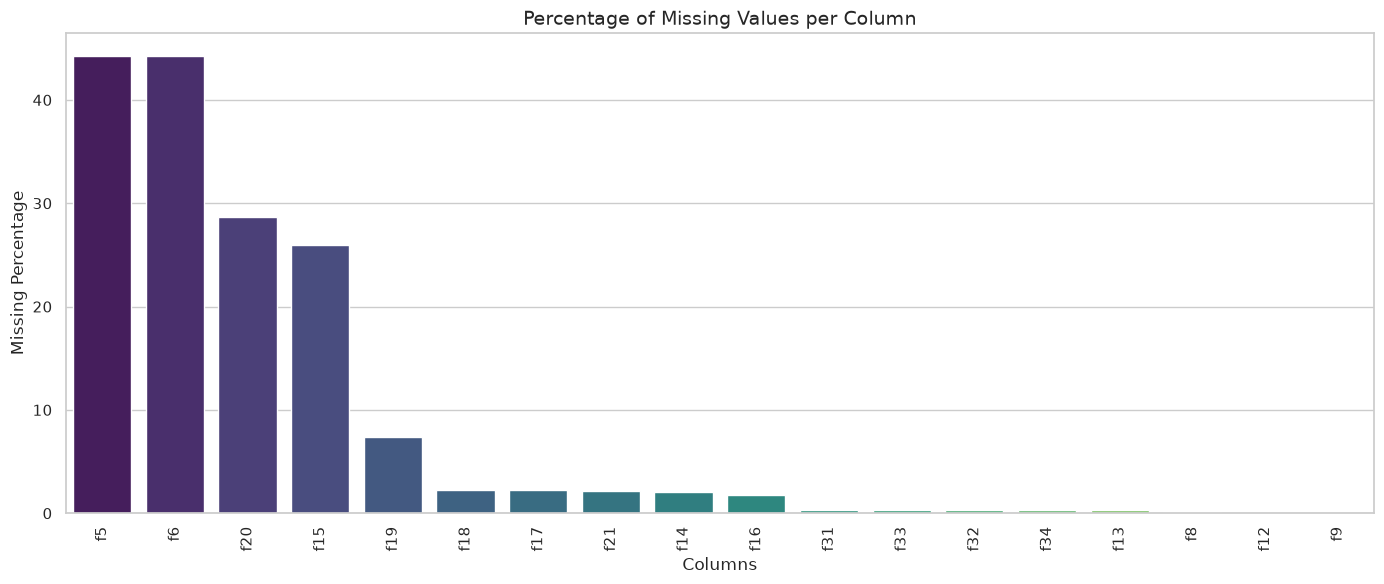

In [54]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

missing_df = missing_df[missing_df['missing_count'] > 0]

display(missing_df)

plt.figure(figsize=(14,6))
sns.barplot(x=missing_df.index, y=missing_df['missing_percent'], palette='viridis')

plt.xticks(rotation=90)
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Percentage')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## بررسی تعداد مقادیر یکتا در ستون‌ها

در این بخش تعداد مقادیر یکتای هر ستون بررسی می‌شود. این تحلیل کمک می‌کند ویژگی‌هایی با **تنوع بسیار کم** یا **تنوع بسیار زیاد (High Cardinality)** شناسایی شوند.

ستون‌هایی با تنوع بسیار کم ممکن است اطلاعات مفیدی برای مدل فراهم نکنند، در حالی که ستون‌هایی با تعداد زیادی مقدار یکتا ممکن است در مراحل بعدی مانند **encoding** یا **feature engineering** نیازمند بررسی دقیق‌تر باشند.

</div>


,unique_values
f2,99407
f3,90725
f4,90686
f6,51577
f5,51573
f12,36879
f8,32428
f9,6406
f7,6177
f13,1616


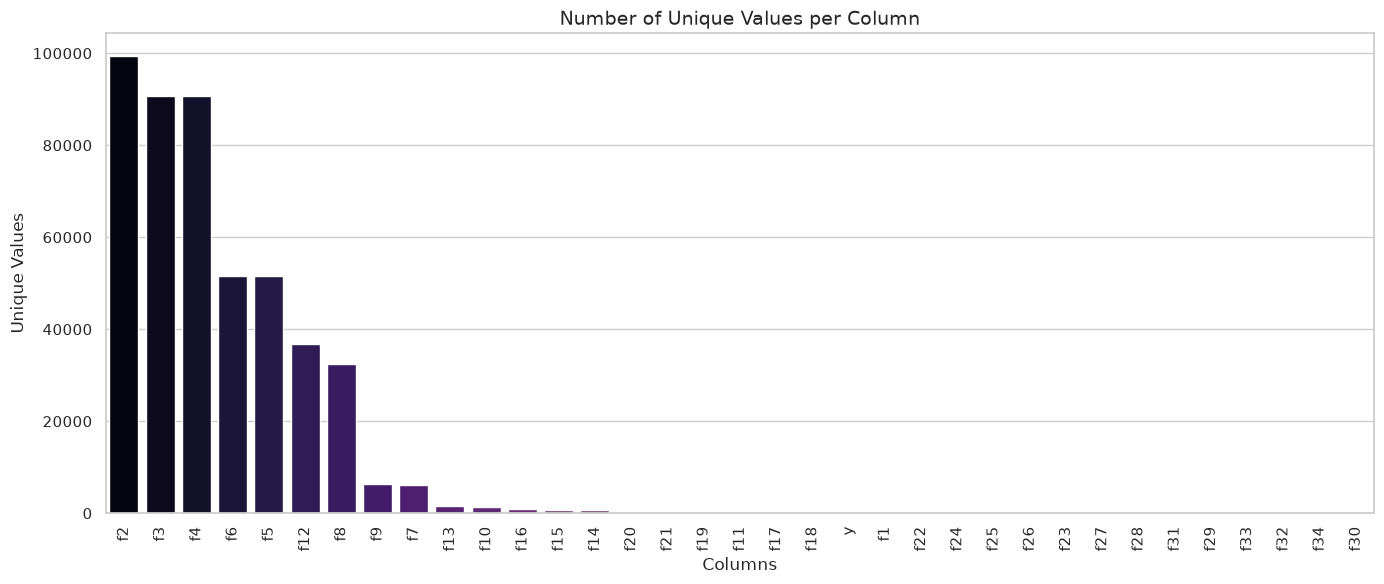

In [55]:
unique_counts = df.nunique().sort_values(ascending=False)

display(unique_counts.to_frame(name='unique_values'))

plt.figure(figsize=(14,6))
sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='magma')

plt.xticks(rotation=90)
plt.title('Number of Unique Values per Column')
plt.ylabel('Unique Values')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## تحلیل متغیر هدف `y`

از آنجا که مسئله حاضر یک **مسئله طبقه‌بندی (Classification)** است، بررسی توزیع کلاس‌های متغیر هدف اهمیت زیادی دارد. اگر توزیع کلاس‌ها نامتوازن باشد، مدل‌های یادگیری ماشین ممکن است در یادگیری کلاس‌های کم‌نمونه دچار مشکل شوند.

در این بخش تعداد و درصد هر کلاس محاسبه شده و با استفاده از نمودارهای میله‌ای و دایره‌ای نمایش داده می‌شود تا وضعیت **تعادل یا عدم تعادل کلاس‌ها** مشخص شود.

</div>


,count,percent
y,,
1,860,0.86
2,79560,79.56
3,16910,16.91
4,2670,2.67


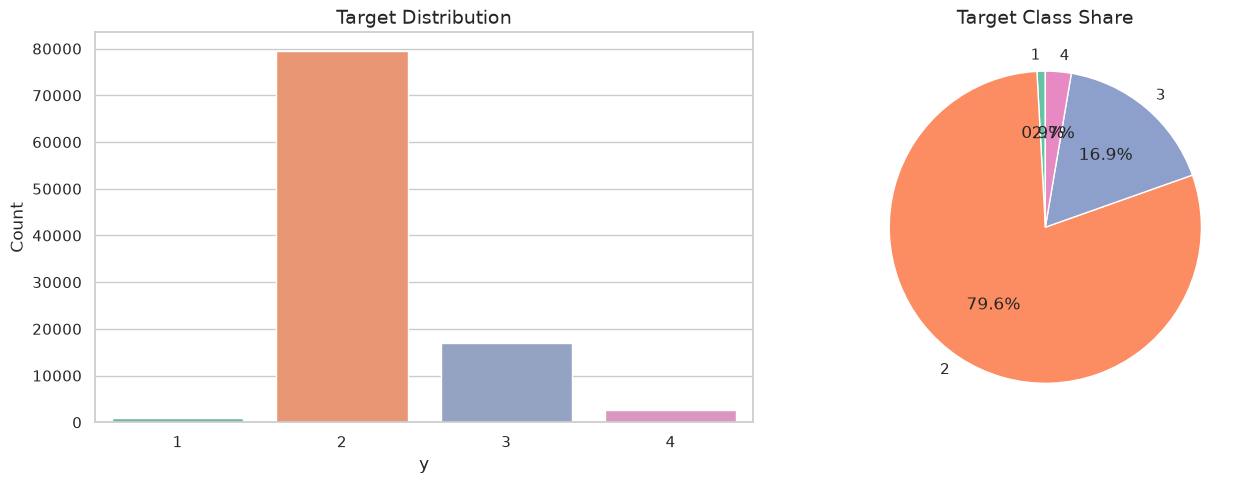

In [56]:
target_counts = df['y'].value_counts().sort_index()
target_percent = df['y'].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    'count': target_counts,
    'percent': target_percent
}))

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.countplot(data=df, x='y', ax=axes[0], palette='Set2')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Count')

axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)

axes[1].set_title('Target Class Share')

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## تحلیل ویژگی‌های زمانی

ستون زمانی `f2` می‌تواند اطلاعات ارزشمندی درباره الگوی زمانی رخدادها ارائه دهد. در این بخش ابتدا این ستون به نوع داده زمانی تبدیل شده و سپس ویژگی‌هایی مانند **ساعت، روز هفته و ماه** از آن استخراج می‌شوند.

تحلیل این ویژگی‌ها می‌تواند الگوهایی مانند زمان‌های پرتکرار رخدادها یا تغییر رفتار متغیر هدف در ساعات مختلف روز را آشکار کند.

</div>


In [57]:
df['f2'] = pd.to_datetime(df['f2'], errors='coerce')
df['hour'] = df['f2'].dt.hour
df['dayofweek'] = df['f2'].dt.dayofweek
df['month'] = df['f2'].dt.month
df['date'] = df['f2'].dt.date

weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['weekday_name'] = df['dayofweek'].map(weekday_map)

month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
df['month_name'] = df['month'].map(month_map)

display(df[['f2', 'hour', 'weekday_name', 'month_name']].head())


,f2,hour,weekday_name,month_name
0,2018-03-30 17:32:46,17.0,Fri,Mar
1,2022-07-27 13:42:00,13.0,Wed,Jul
2,2022-06-06 13:00:30,13.0,Mon,Jun
3,2021-09-07 21:50:00,21.0,Tue,Sep
4,2019-05-23 20:52:35,20.0,Thu,May


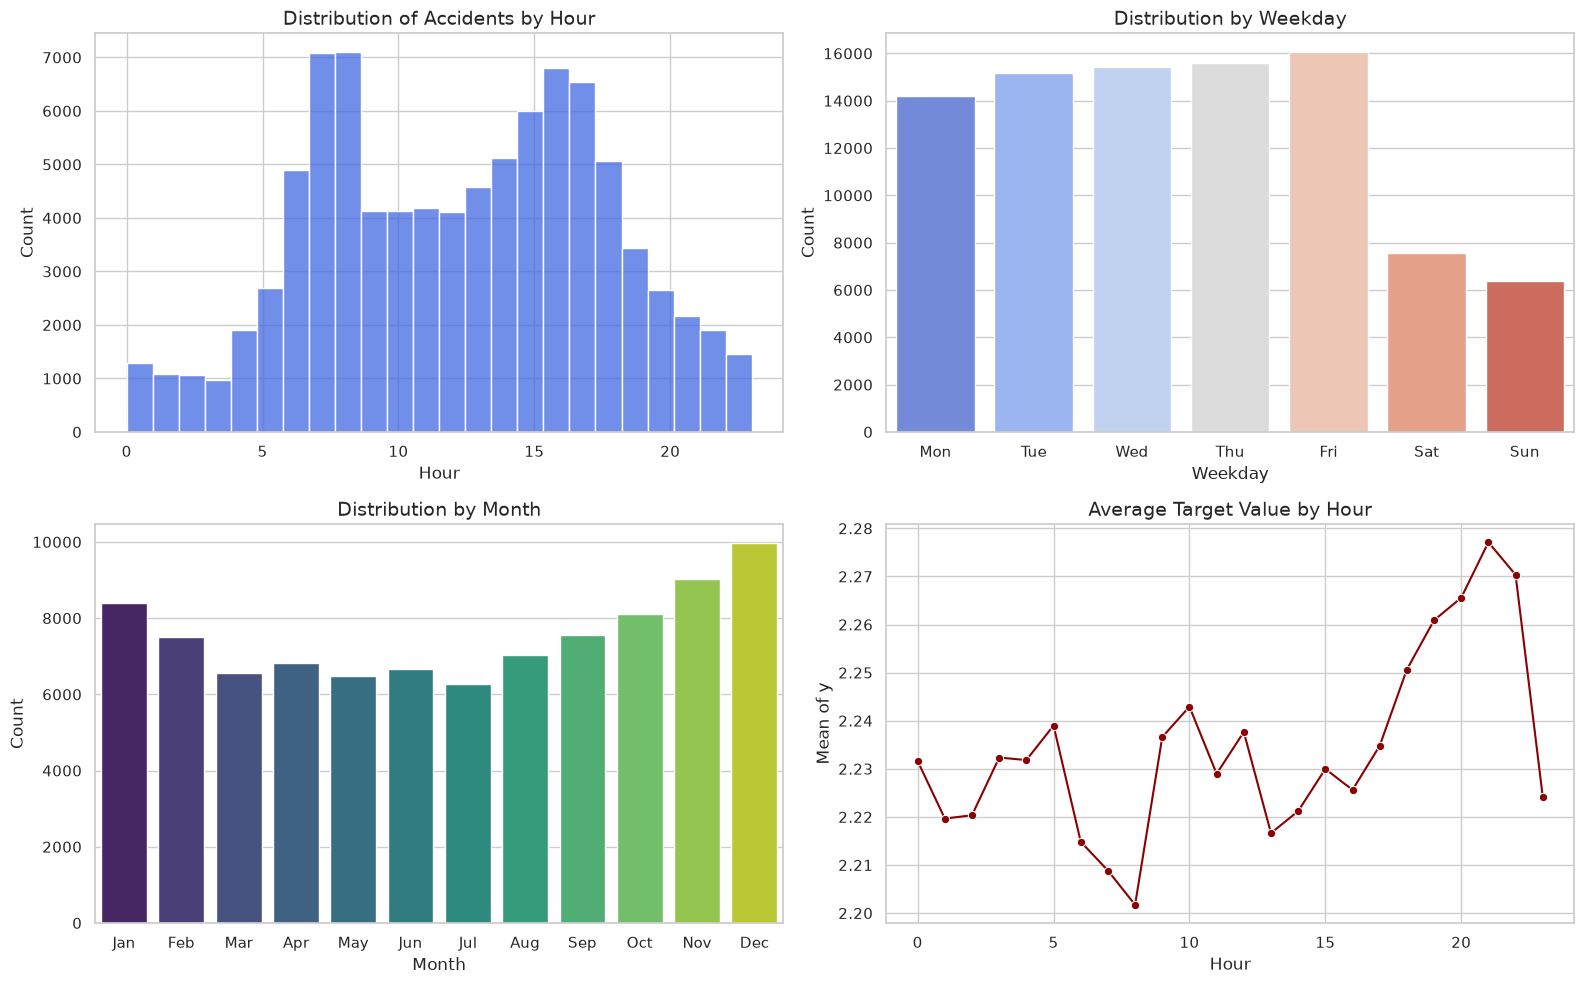

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df['hour'].dropna(), bins=24, kde=False, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('Distribution of Accidents by Hour')
axes[0, 0].set_xlabel('Hour')

sns.countplot(data=df, x='weekday_name', order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Distribution by Weekday')
axes[0, 1].set_xlabel('Weekday')
axes[0, 1].set_ylabel('Count')

sns.countplot(data=df, x='month_name', order=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Distribution by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Count')

hour_target = df.groupby('hour')['y'].mean()
sns.lineplot(x=hour_target.index, y=hour_target.values, marker='o', ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('Average Target Value by Hour')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Mean of y')

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## تحلیل ویژگی‌های مکانی و جغرافیایی

ویژگی‌های مکانی می‌توانند اطلاعات مهمی درباره محل وقوع رخدادها ارائه دهند. در این بخش ابتدا تعداد مقادیر یکتای برخی ستون‌های مرتبط با موقعیت مکانی بررسی می‌شود.

سپس با استفاده از نمودارهای میله‌ای، پرتکرارترین استان‌ها و شهرها نمایش داده می‌شوند. همچنین با استفاده از مختصات جغرافیایی، پراکندگی مکانی داده‌ها به صورت نمودار پراکندگی بررسی می‌شود تا الگوهای فضایی احتمالی مشخص شوند.

</div>


f10: 1303
f11: 49
f12: 36879


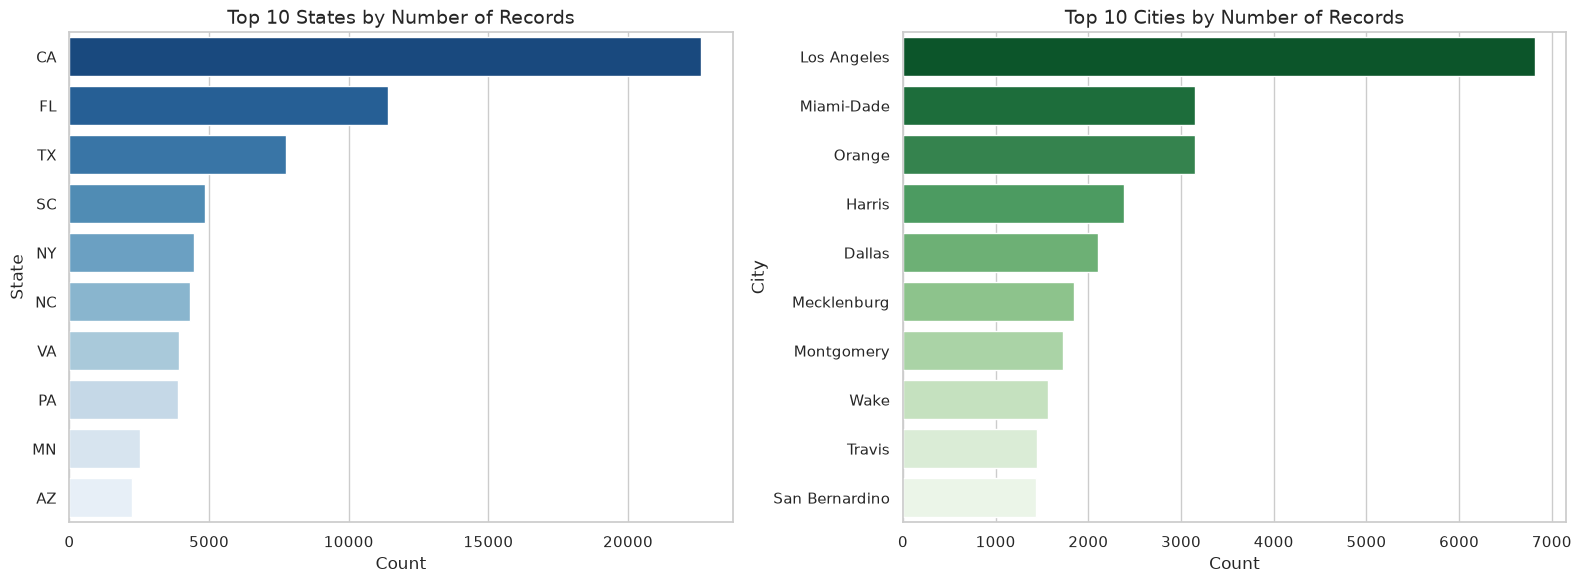

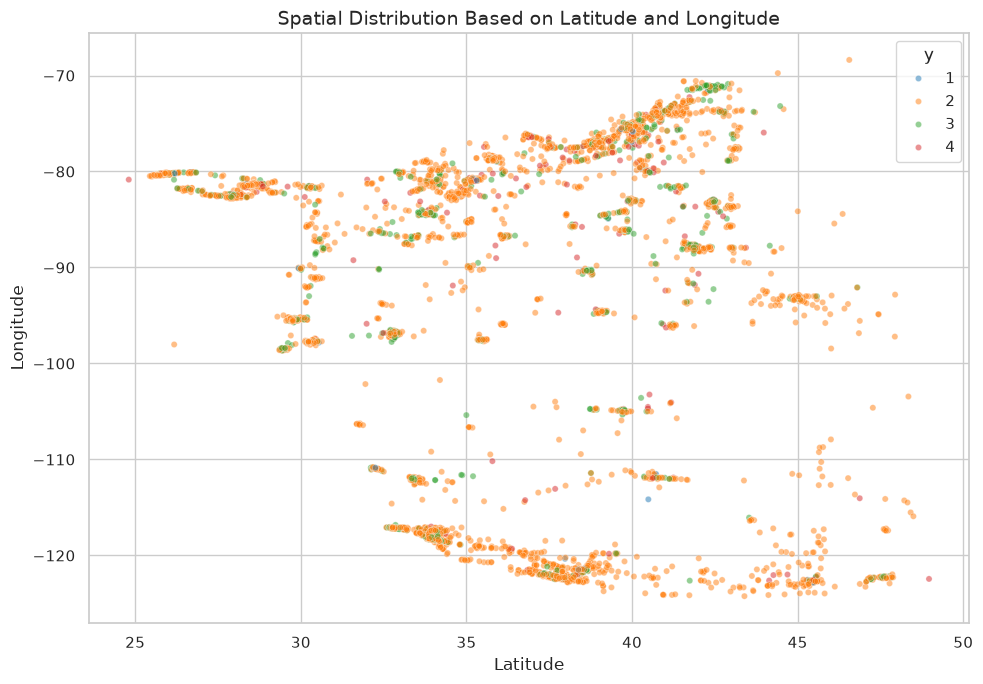

In [59]:
for col in ['f10', 'f11', 'f12']:
    print(f'{col}:', df[col].nunique(dropna=True))

state_counts = df['f11'].value_counts().head(10)
city_counts = df['f10'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=state_counts.values, y=state_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 States by Number of Records')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('State')

sns.barplot(x=city_counts.values, y=city_counts.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Cities by Number of Records')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('City')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x='f3', y='f4', hue='y', palette='tab10', alpha=0.5, s=20)
plt.title('Spatial Distribution Based on Latitude and Longitude')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## تحلیل توزیع ویژگی‌های دسته‌ای

در این بخش ستون‌های دسته‌ای دیتاست بررسی می‌شوند. برای هر ستون، پرتکرارترین مقادیر نمایش داده می‌شود تا نحوه توزیع دسته‌ها مشخص شود.

این تحلیل کمک می‌کند دسته‌هایی که سهم بیشتری از داده‌ها دارند یا ستون‌هایی که تنوع محدودی دارند شناسایی شوند.

</div>


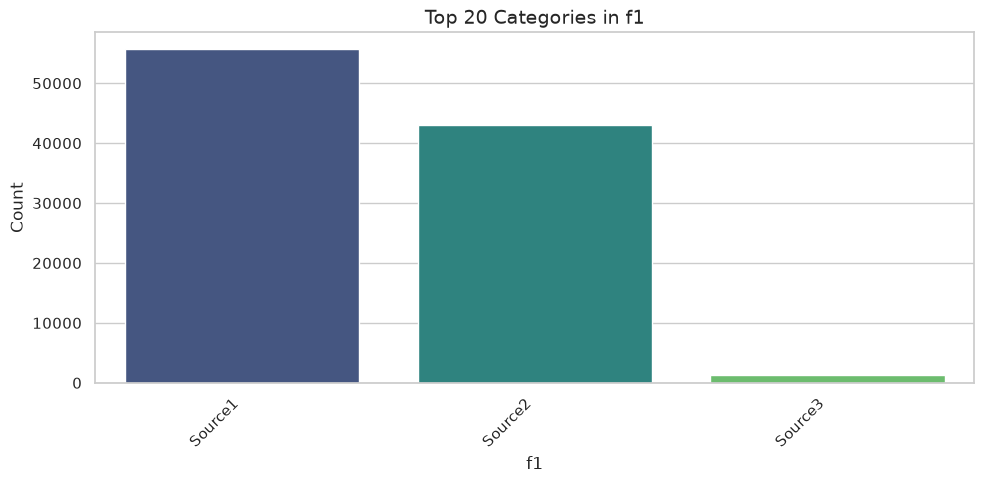

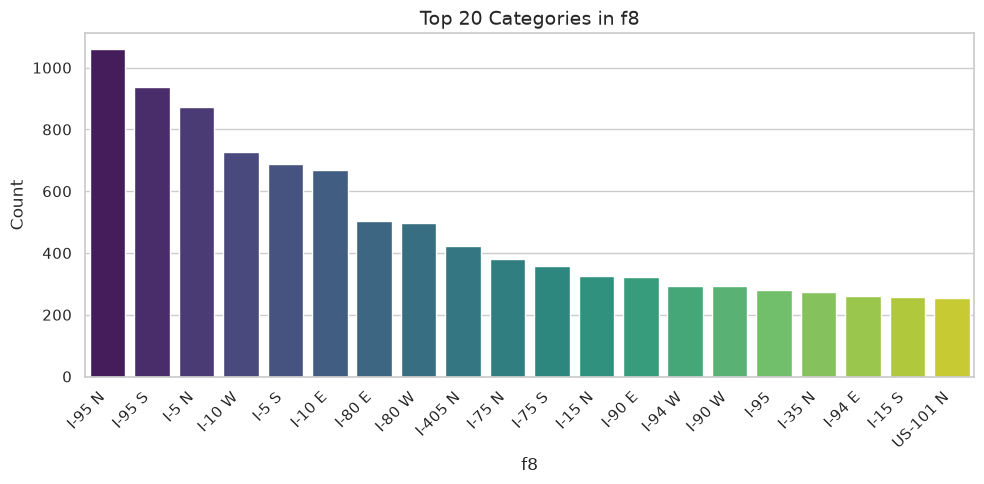

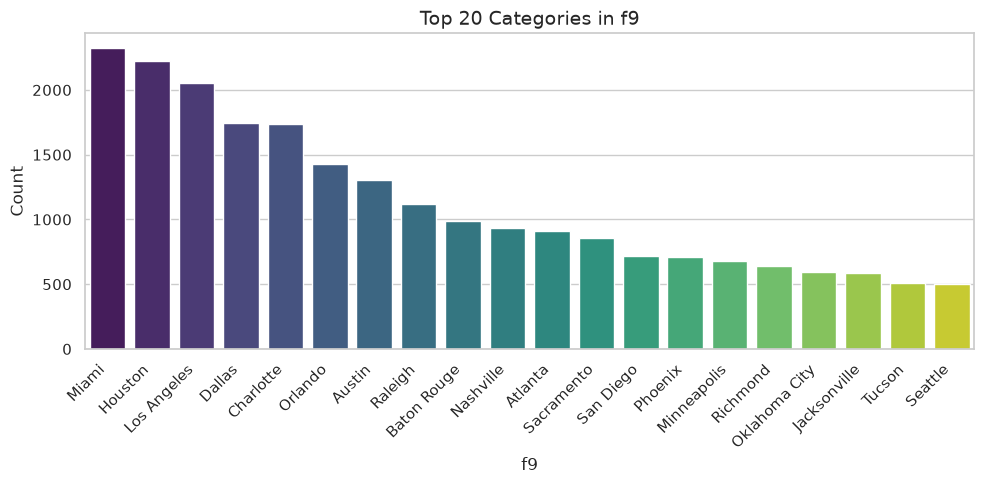

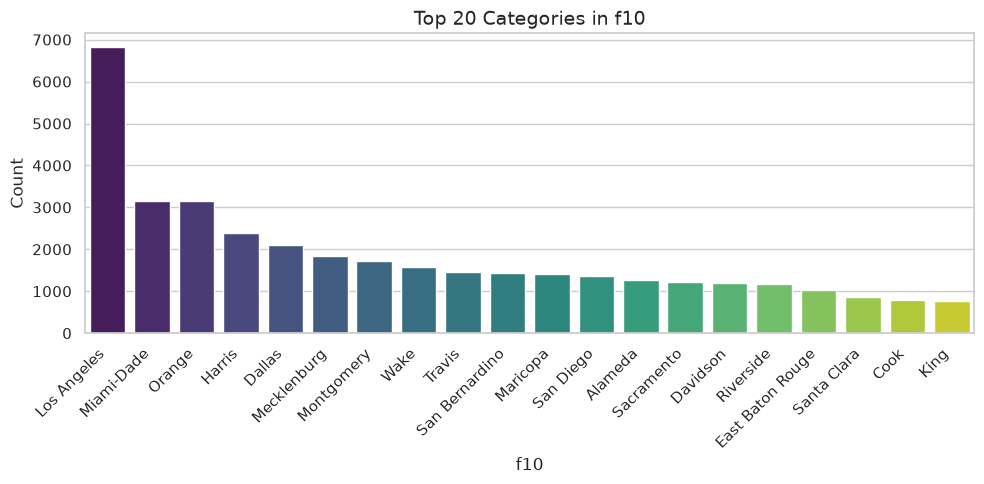

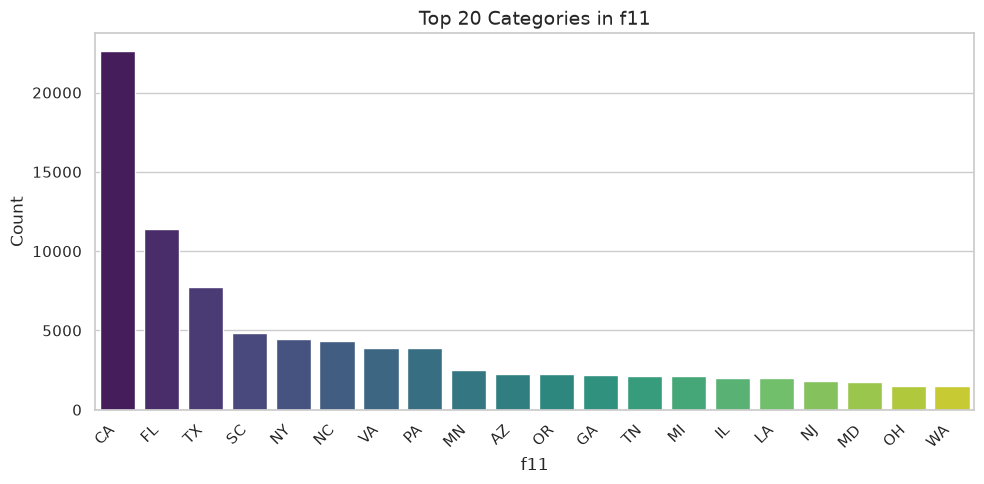

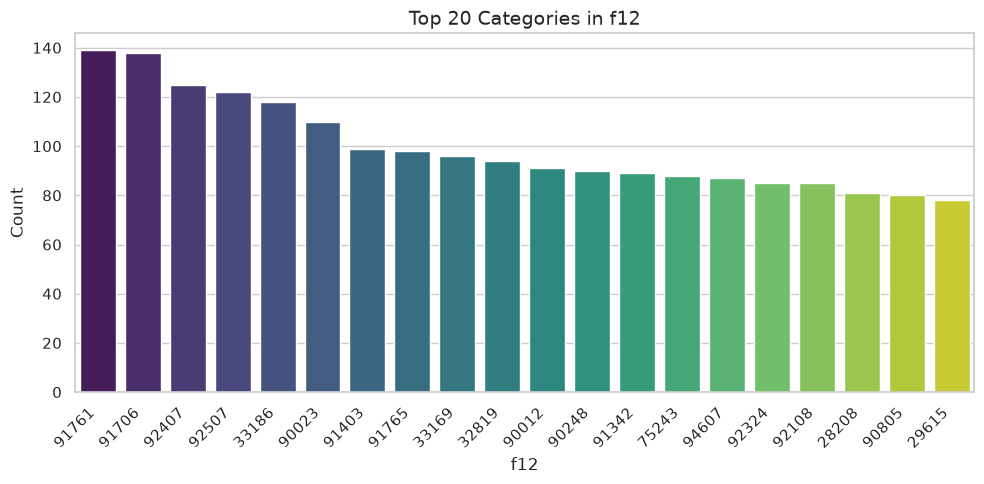

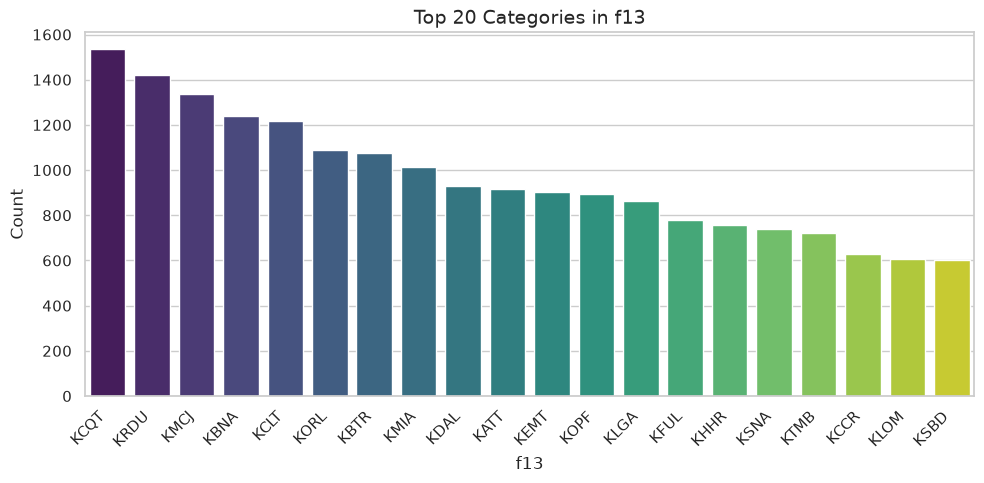

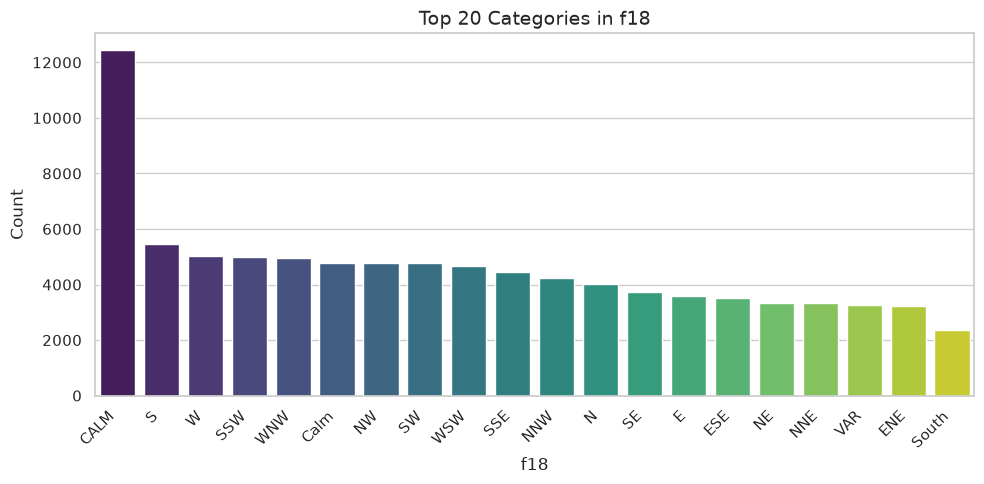

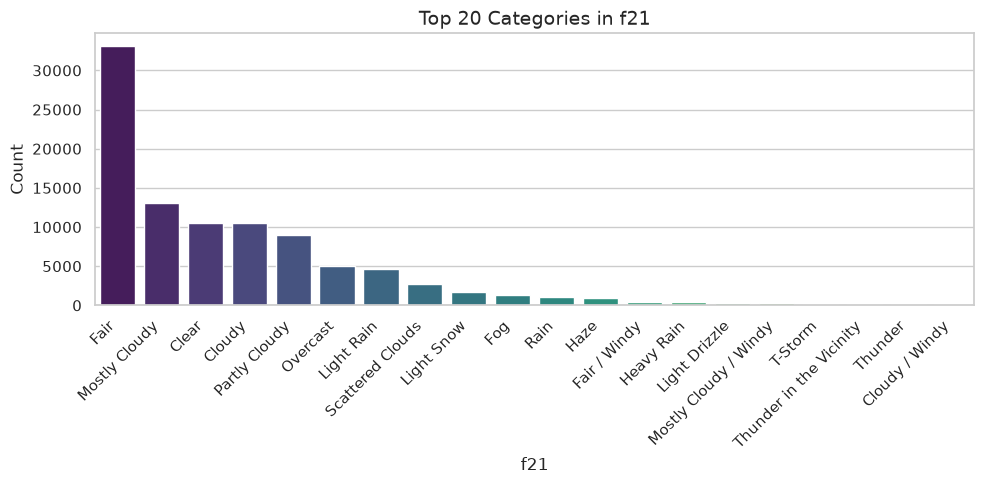

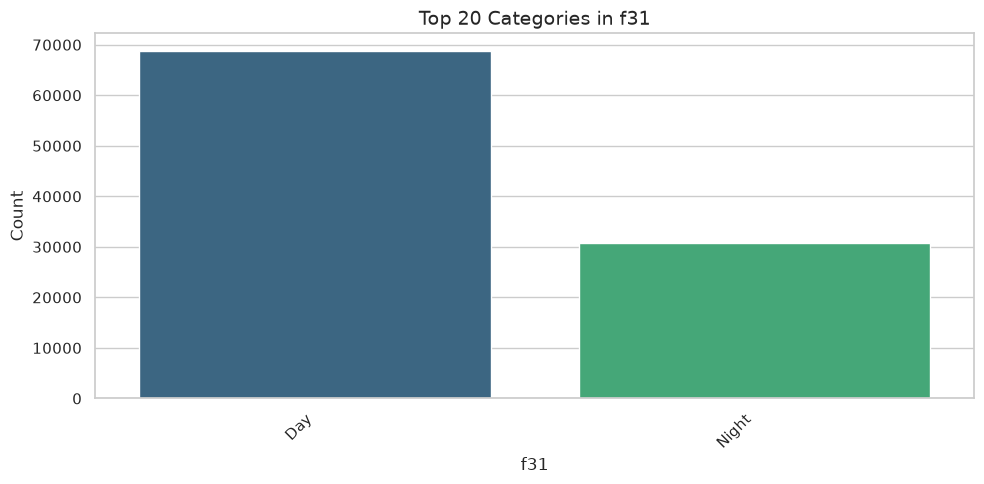

In [60]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'f2']

for col in cat_cols[:10]:
    top_counts = df[col].value_counts().head(20)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_counts.index, y=top_counts.values, palette='viridis')
    plt.title(f'Top 20 Categories in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## تحلیل وابستگی بین ویژگی‌های دسته‌ای

در این بخش وابستگی بین ویژگی‌های دسته‌ای با استفاده از شاخص **Cramér's V** بررسی می‌شود. این شاخص بر پایه آزمون **Chi‑Square** محاسبه شده و میزان وابستگی بین دو متغیر دسته‌ای را اندازه‌گیری می‌کند.

مقادیر این شاخص بین **0 تا 1** قرار دارند؛ مقدار نزدیک به صفر نشان‌دهنده نبود رابطه و مقدار نزدیک به یک نشان‌دهنده وابستگی قوی بین دو ویژگی است.

</div>


Categorical columns used:
['f1', 'f11', 'f18', 'f21', 'f31', 'f32', 'f33', 'f34', 'weekday_name', 'month_name']


,f1,f11,f18,f21,f31,f32,f33,f34,weekday_name,month_name
f1,1.000000,0.225348,0.230635,0.260120,0.117731,0.136716,0.141271,0.149883,0.097099,0.106766
f11,0.225348,1.000000,0.130461,0.132907,0.131138,0.141414,0.142832,0.143102,0.117681,0.099346
f18,0.230635,0.130461,1.000000,0.167359,0.181213,0.172132,0.151852,0.138445,0.080923,0.085129
f21,0.260120,0.132907,0.167359,1.000000,0.184702,0.182629,0.187905,0.185626,0.112657,0.133642
f31,0.117731,0.131138,0.181213,0.184702,1.000000,0.879004,0.749330,0.662003,0.094447,0.275933
f32,0.136716,0.141414,0.172132,0.182629,0.879004,1.000000,0.852035,0.752840,0.107533,0.270769
f33,0.141271,0.142832,0.151852,0.187905,0.749330,0.852035,1.000000,0.883135,0.108142,0.234350
f34,0.149883,0.143102,0.138445,0.185626,0.662003,0.752840,0.883135,1.000000,0.115684,0.230760
weekday_name,0.097099,0.117681,0.080923,0.112657,0.094447,0.107533,0.108142,0.115684,1.000000,0.040841
month_name,0.106766,0.099346,0.085129,0.133642,0.275933,0.270769,0.234350,0.230760,0.040841,1.000000


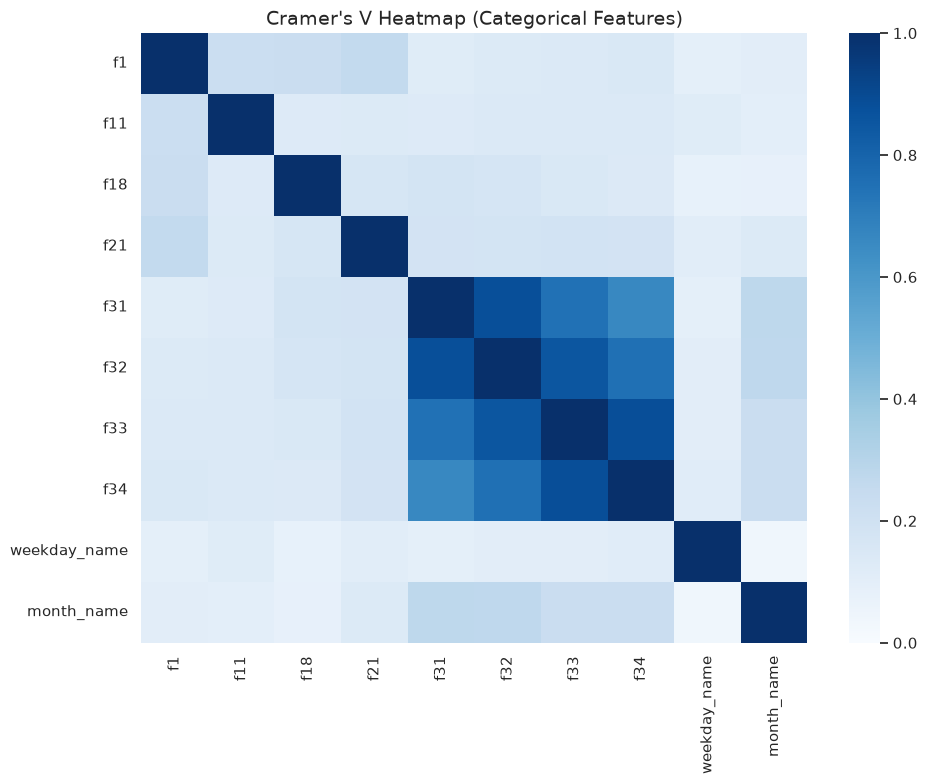

In [61]:
from scipy.stats import chi2_contingency
import numpy as np

# --------- Cramer's V function ---------
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    if confusion_matrix.empty:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape

    if n == 0 or min(r - 1, k - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


# --------- 1. sample data (for speed) ---------
sample_size = min(5000, len(df))
sample_df = df.sample(sample_size, random_state=42)


# --------- 2. select categorical columns ---------
cat_cols = sample_df.select_dtypes(include=['object', 'category']).columns.tolist()

# حذف ستون زمانی
cat_cols = [c for c in cat_cols if c != 'f2']

# حذف ستون‌هایی با تعداد category خیلی زیاد
cat_cols = [c for c in cat_cols if sample_df[c].nunique() <= 50]

# محدود کردن تعداد ستون‌ها برای سرعت
cat_cols = cat_cols[:10]

print("Categorical columns used:")
print(cat_cols)


# --------- 3. compute Cramer's V matrix ---------
cramers_matrix = pd.DataFrame(
    np.eye(len(cat_cols)),
    index=cat_cols,
    columns=cat_cols
)

for i, col1 in enumerate(cat_cols):
    for j, col2 in enumerate(cat_cols):
        if i < j:
            val = cramers_v(sample_df[col1], sample_df[col2])
            cramers_matrix.loc[col1, col2] = val
            cramers_matrix.loc[col2, col1] = val


display(cramers_matrix)


# --------- 4. visualization ---------
plt.figure(figsize=(10,8))
sns.heatmap(cramers_matrix, cmap='Blues', vmin=0, vmax=1)
plt.title("Cramer's V Heatmap (Categorical Features)")
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## بررسی ارتباط ویژگی‌های دسته‌ای با متغیر هدف

در این بخش بررسی می‌کنیم که آیا مقادیر مختلف ویژگی‌های دسته‌ای می‌توانند بر مقدار متغیر هدف `y` تأثیر بگذارند یا خیر.

برای هر دسته از یک ویژگی، میانگین مقدار متغیر هدف محاسبه می‌شود. از آنجا که متغیر هدف دودویی است، این مقدار در واقع نشان‌دهنده **احتمال وقوع کلاس مثبت** در هر دسته است.

</div>


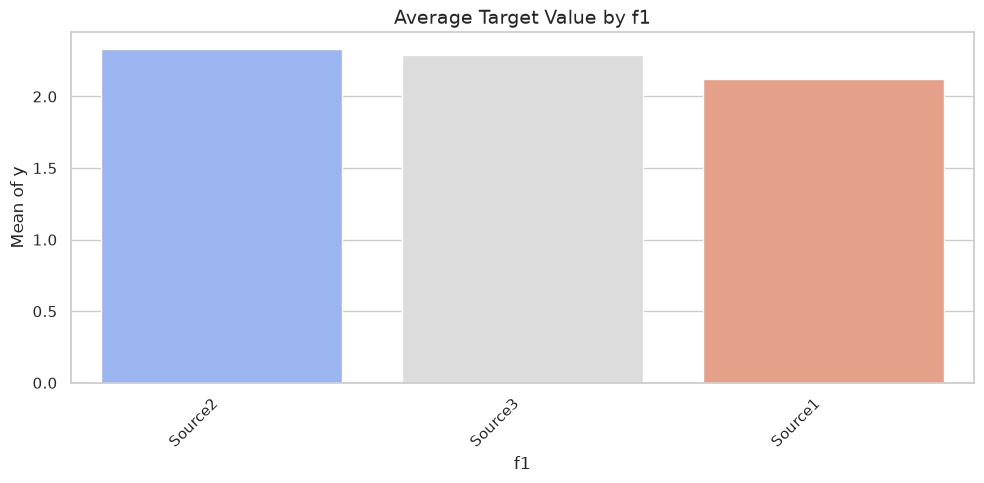

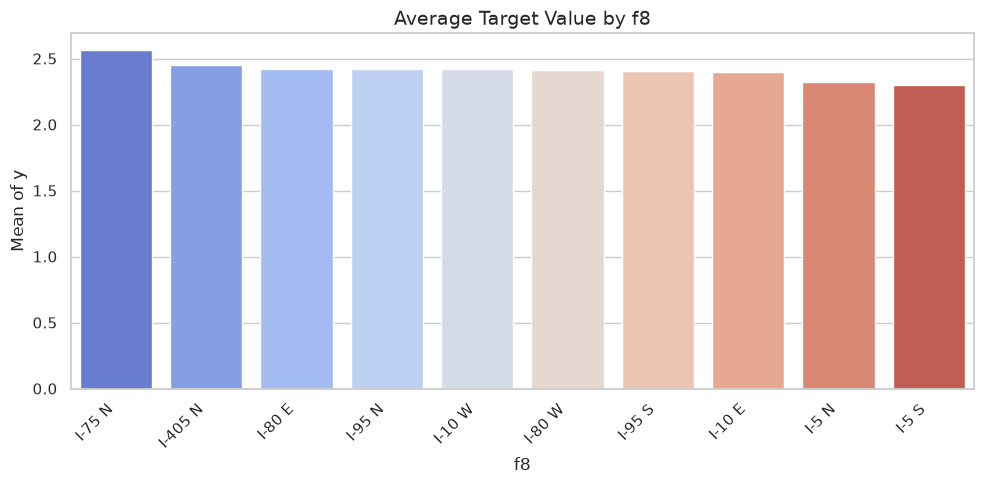

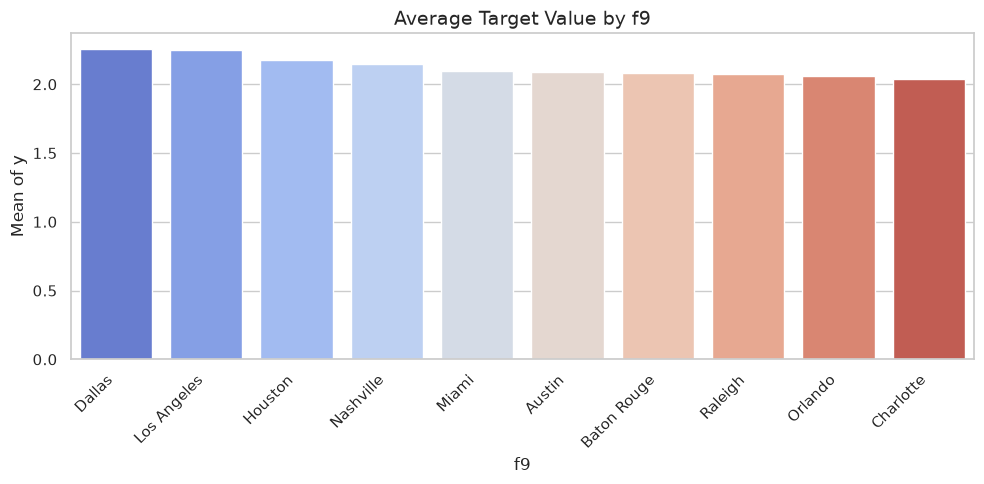

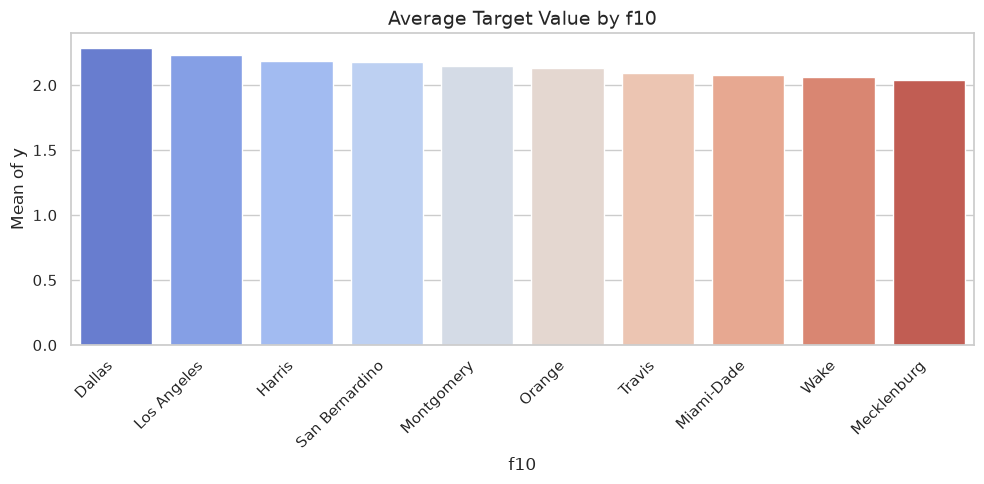

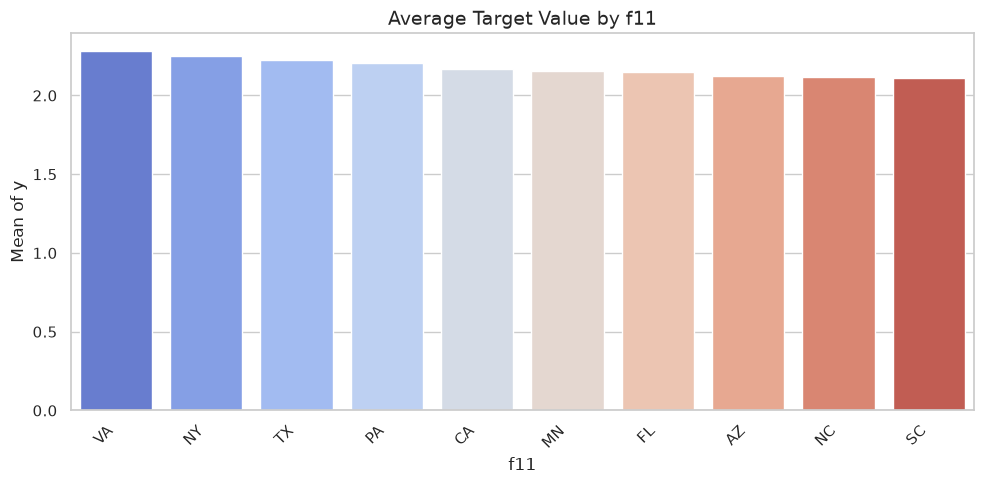

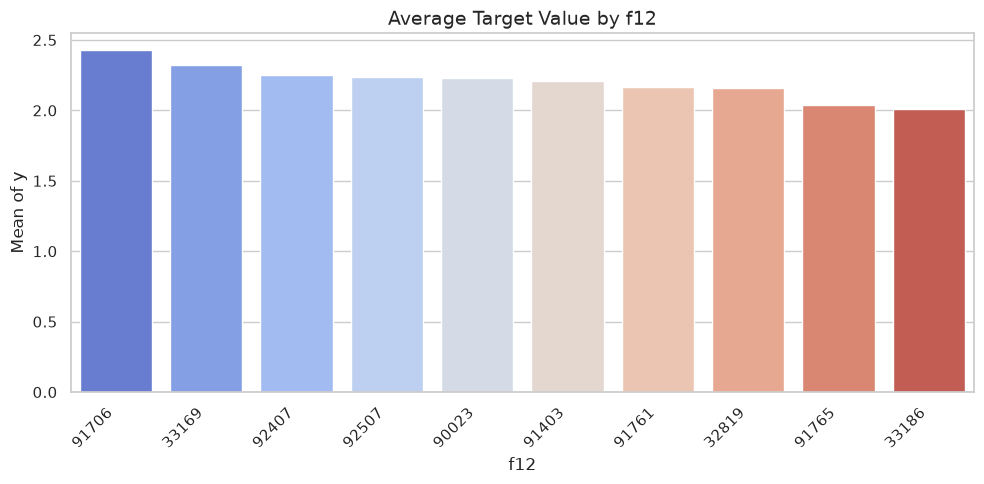

In [62]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'f2']

for col in cat_cols[:6]:

    top_categories = df[col].value_counts().head(10).index
    temp = df[df[col].isin(top_categories)]

    target_mean = temp.groupby(col)['y'].mean().sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    sns.barplot(x=target_mean.index, y=target_mean.values, palette='coolwarm')

    plt.title(f'Average Target Value by {col}')
    plt.xlabel(col)
    plt.ylabel('Mean of y')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## بررسی رابطه ویژگی‌های عددی با متغیر هدف

در این بخش ارتباط بین ویژگی‌های عددی و متغیر هدف `y` بررسی می‌شود. برای این منظور از **ضریب همبستگی پیرسون (Pearson Correlation)** استفاده می‌شود.

این تحلیل کمک می‌کند ویژگی‌هایی که بیشترین ارتباط خطی را با متغیر هدف دارند شناسایی شوند و در مراحل بعدی مدل‌سازی مورد توجه قرار گیرند.

</div>


,corr_with_y
f6,0.091788
f5,0.081675
f3,0.066915
f4,0.050558
f7,0.037251
f19,0.036252
f16,0.034426
dayofweek,0.029295
f20,0.026736
hour,0.021859


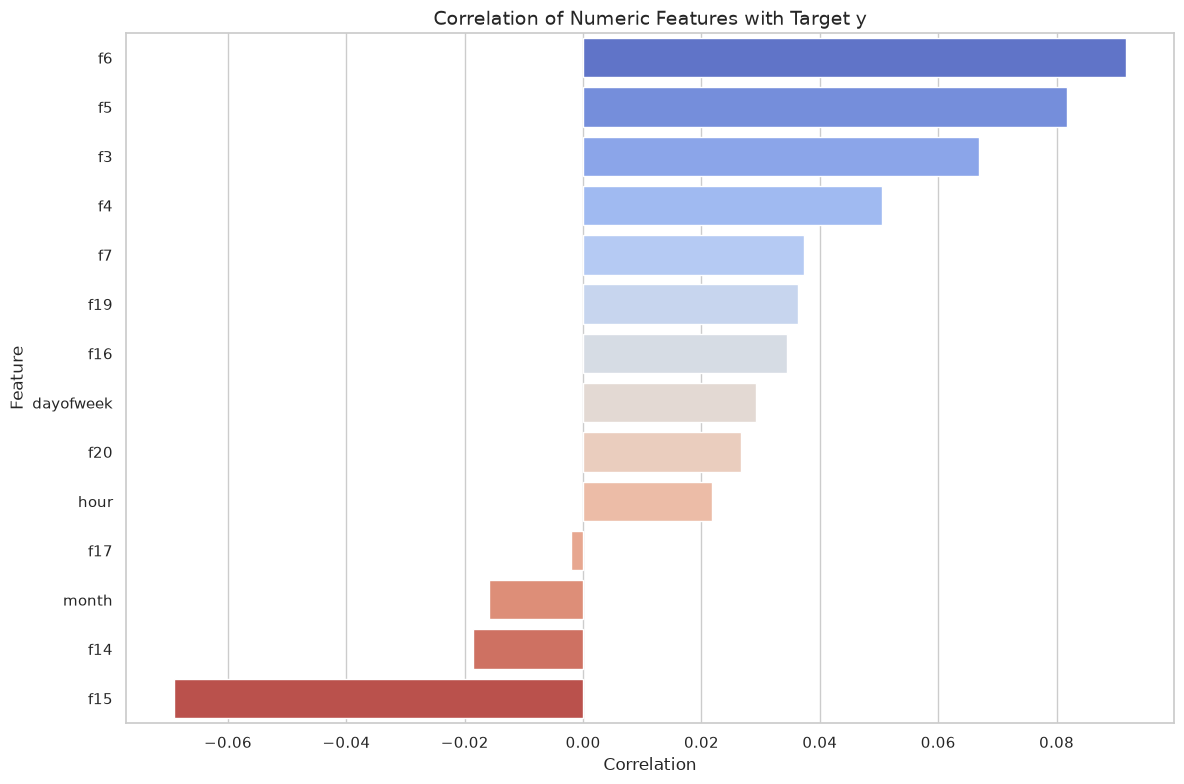

In [63]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'y']

corr_with_target = df[numeric_cols + ['y']].corr(numeric_only=True)['y'].drop('y').sort_values(ascending=False)

display(corr_with_target.to_frame(name='corr_with_y'))

plt.figure(figsize=(12,8))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Correlation of Numeric Features with Target y')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## ماتریس همبستگی بین ویژگی‌های عددی

در این بخش ماتریس همبستگی بین تمامی ویژگی‌های عددی محاسبه و به صورت **Heatmap** نمایش داده می‌شود.

این نمودار کمک می‌کند ویژگی‌هایی که ارتباط بسیار بالایی با یکدیگر دارند شناسایی شوند. چنین ویژگی‌هایی ممکن است اطلاعات مشابهی داشته باشند و در مراحل بعدی **Feature Selection** مورد بررسی قرار گیرند.

</div>


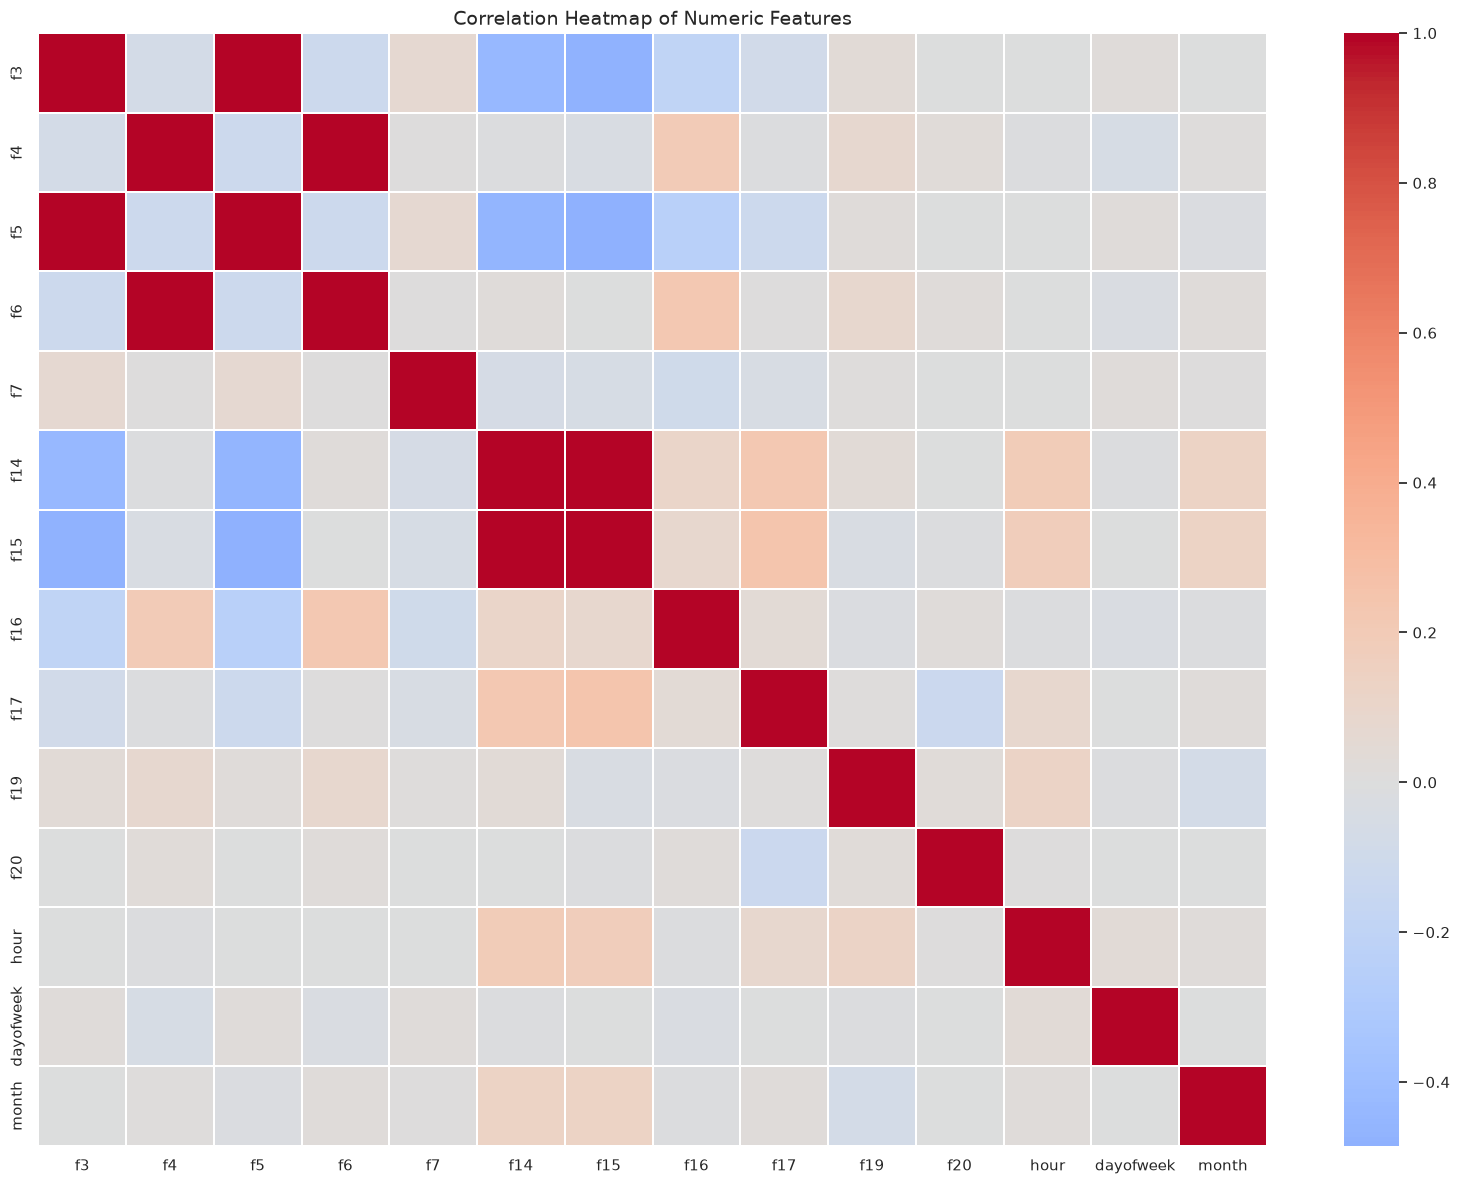

In [64]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'y']

corr_matrix = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## بررسی روابط بین ویژگی‌های عددی با Pair Plot

برای بررسی روابط جفتی بین ویژگی‌های عددی از نمودار **Pair Plot** استفاده می‌شود. این نمودار توزیع هر متغیر را در قطر اصلی نمایش داده و روابط بین متغیرها را در سایر بخش‌ها نشان می‌دهد.

برای جلوگیری از سنگین شدن محاسبات، تنها چند ویژگی عددی به همراه متغیر هدف انتخاب شده و نمودار بر روی **نمونه‌ای از داده‌ها** رسم شده است.

</div>


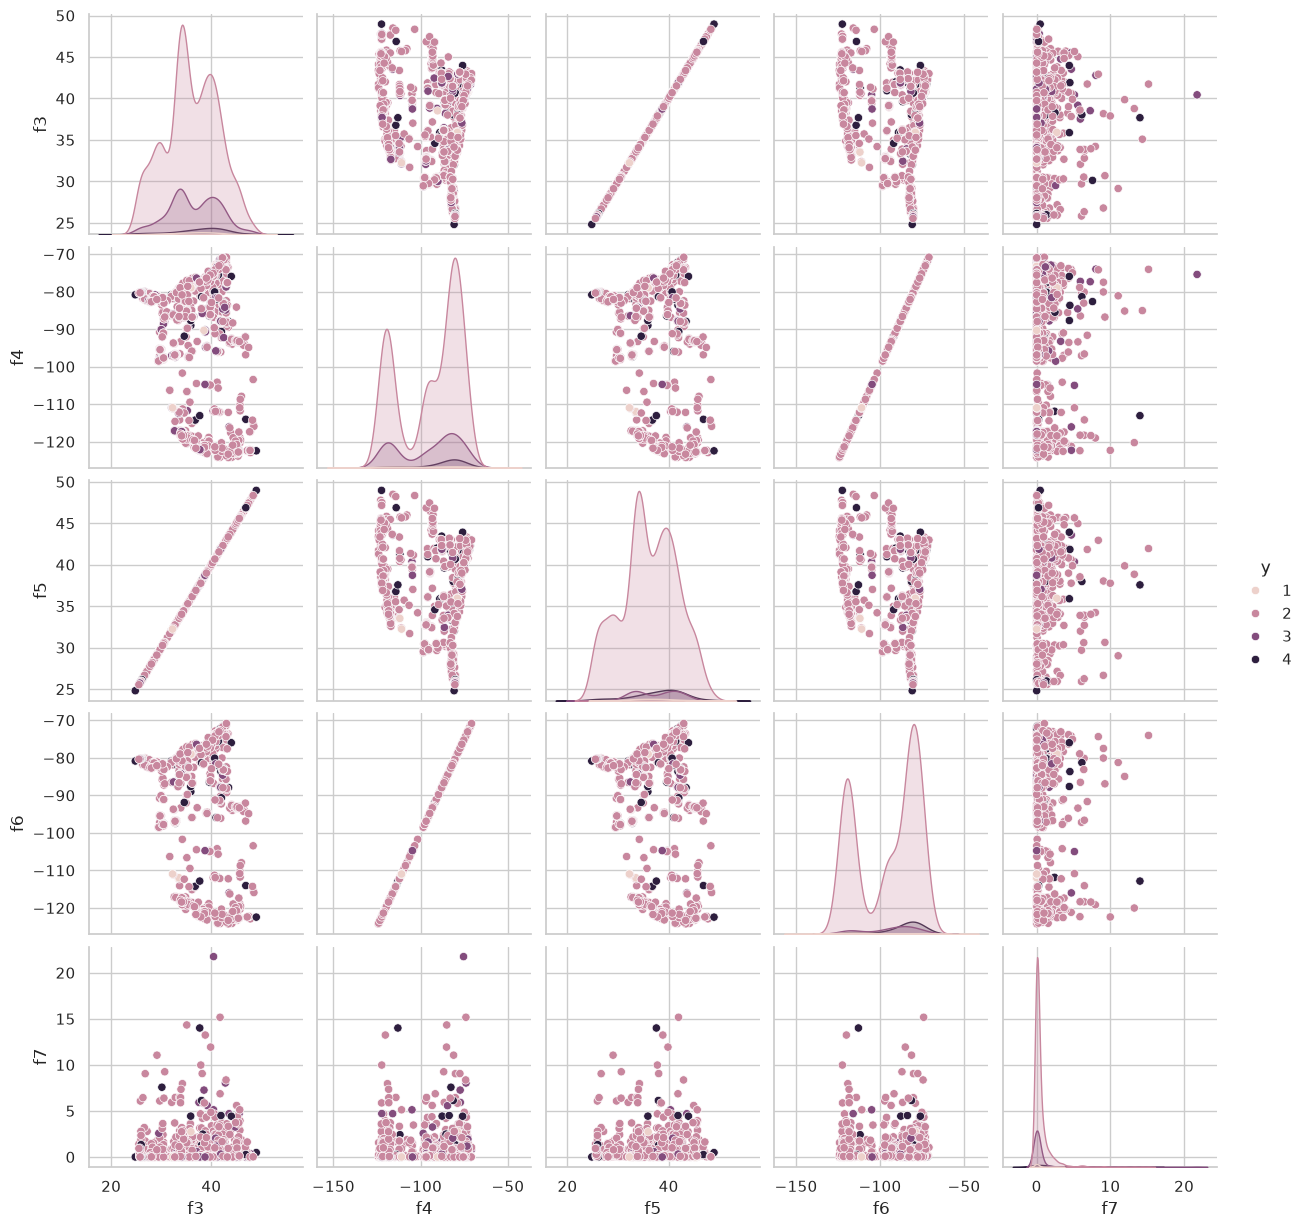

In [65]:
target = 'y'
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != target]

subset = num_cols[:5] + [target]
sample_df = df[subset].sample(min(2000, len(df)), random_state=42)

sns.pairplot(sample_df, hue=target)
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## تحلیل ویژگی‌های باینری

در برخی از ستون‌های دیتاست مقادیر به صورت **True/False** ذخیره شده‌اند. این نوع متغیرها نشان‌دهنده وجود یا عدم وجود یک ویژگی خاص هستند.

در این بخش ستون‌های باینری شناسایی شده و نسبت مقادیر True در هر ویژگی بررسی می‌شود تا مشخص شود کدام شرایط بیشتر در داده‌ها رخ داده‌اند.

</div>


Binary columns: ['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30']


,true_count,false_count
f22,1234,98766
f23,47,99953
f24,7315,92685
f25,886,99114
f26,3,99997
f27,2919,97081
f28,104,99896
f29,14681,85319
f30,0,100000


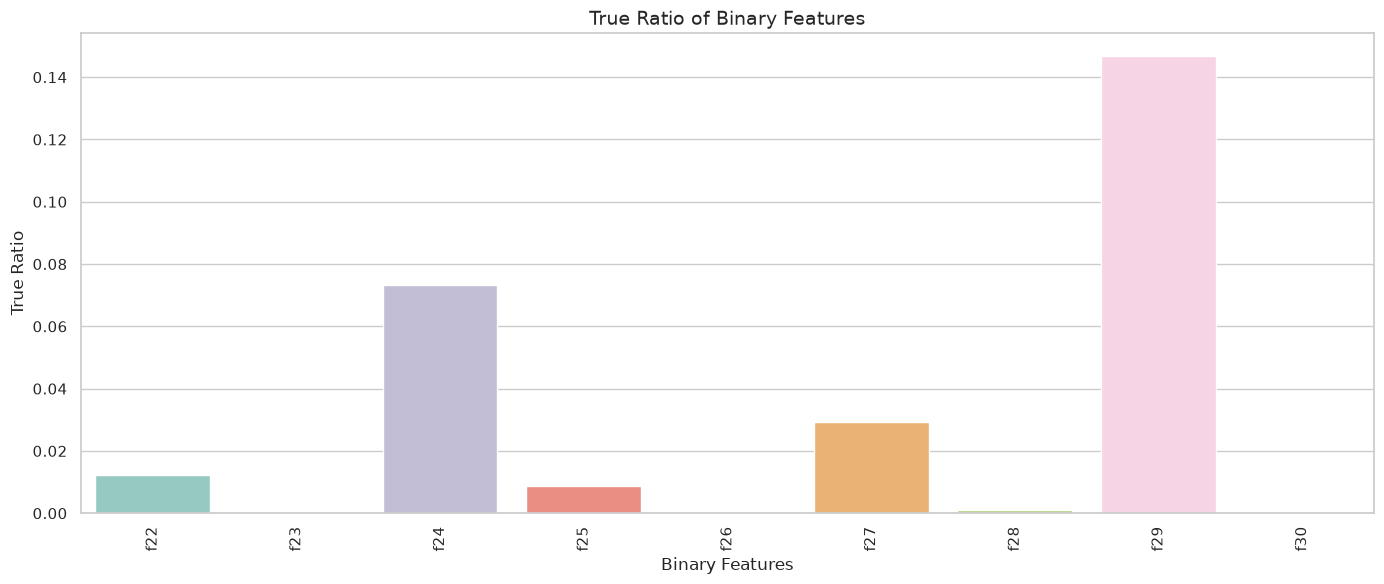

In [66]:
binary_cols = [col for col in df.columns if df[col].dropna().isin([True, False]).all()]
print('Binary columns:', binary_cols)

binary_summary = pd.DataFrame({
    'true_count': df[binary_cols].sum(numeric_only=True),
    'false_count': df[binary_cols].shape[0] - df[binary_cols].sum(numeric_only=True)
})
display(binary_summary)

binary_summary['true_ratio'] = binary_summary['true_count'] / (binary_summary['true_count'] + binary_summary['false_count'])
plt.figure(figsize=(14, 6))
sns.barplot(x=binary_summary.index, y=binary_summary['true_ratio'], palette='Set3')
plt.xticks(rotation=90)
plt.title('True Ratio of Binary Features')
plt.ylabel('True Ratio')
plt.xlabel('Binary Features')
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## تحلیل همبستگی بین ویژگی‌های باینری

در این بخش رابطه بین ویژگی‌های باینری بررسی می‌شود. با تبدیل مقادیر True و False به مقادیر 1 و 0 می‌توان از ضریب همبستگی پیرسون برای اندازه‌گیری میزان وابستگی بین آن‌ها استفاده کرد.

نمایش این روابط در قالب **Heatmap** کمک می‌کند ویژگی‌هایی که رفتار مشابهی دارند شناسایی شوند.

</div>


Boolean columns:
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30']


,f22,f23,f24,f25,f26,f27,f28,f29,f30
f22,1.000000,0.005935,-0.025488,0.048395,-0.000612,0.026893,0.030117,0.107965,NaN
f23,0.005935,1.000000,-0.004320,-0.002050,-0.000119,0.020907,0.672061,-0.003781,NaN
f24,-0.025488,-0.004320,1.000000,-0.010988,0.012485,-0.036850,-0.004298,-0.102862,NaN
f25,0.048395,-0.002050,-0.010988,1.000000,-0.000518,0.012132,0.000260,0.058171,NaN
f26,-0.000612,-0.000119,0.012485,-0.000518,1.000000,0.009896,-0.000177,-0.002272,NaN
f27,0.026893,0.020907,-0.036850,0.012132,0.009896,1.000000,0.031265,-0.051116,NaN
f28,0.030117,0.672061,-0.004298,0.000260,-0.000177,0.031265,1.000000,0.010284,NaN
f29,0.107965,-0.003781,-0.102862,0.058171,-0.002272,-0.051116,0.010284,1.000000,NaN
f30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


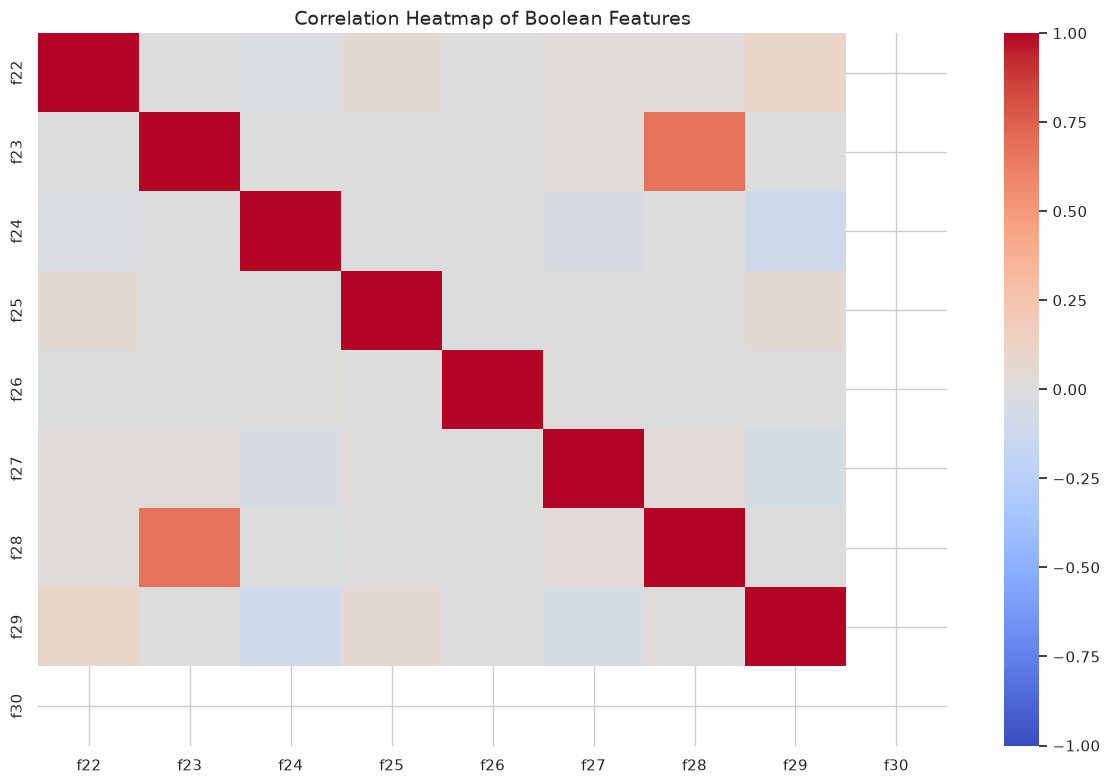

In [67]:
binary_cols = [col for col in df.columns if df[col].dropna().isin([True, False]).all()]

print("Boolean columns:")
print(binary_cols)

binary_df = df[binary_cols].astype(int)

binary_corr = binary_df.corr()

display(binary_corr)

plt.figure(figsize=(12,8))
sns.heatmap(binary_corr, cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title("Correlation Heatmap of Boolean Features")

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right; line-height: 1.8;">

## بررسی رابطه ویژگی‌های باینری با متغیر هدف

در این بخش رابطه بین ویژگی‌های باینری و متغیر هدف `y` بررسی می‌شود. برای هر ویژگی باینری، میانگین مقدار متغیر هدف در دو حالت **True** و **False** محاسبه می‌شود.

از آنجا که متغیر هدف دودویی است، میانگین آن نشان‌دهنده **احتمال وقوع کلاس مثبت** در هر یک از این حالت‌ها است. مقایسه این مقادیر می‌تواند نشان دهد که وجود یا عدم وجود یک ویژگی باینری چه تأثیری بر متغیر هدف دارد.

</div>


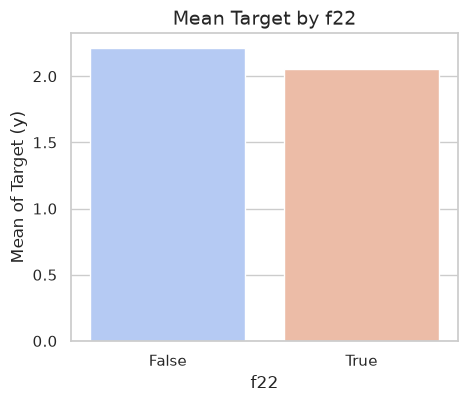

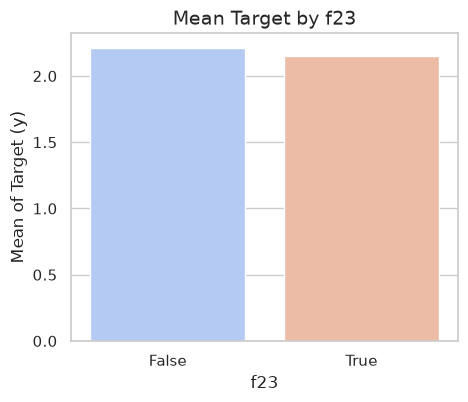

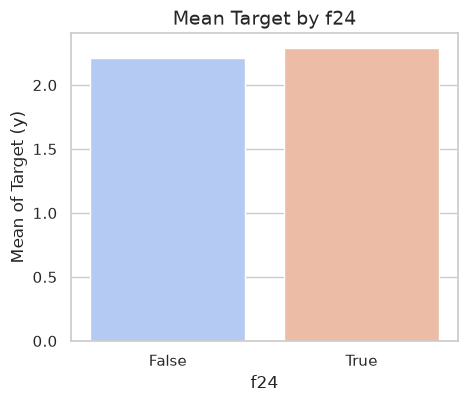

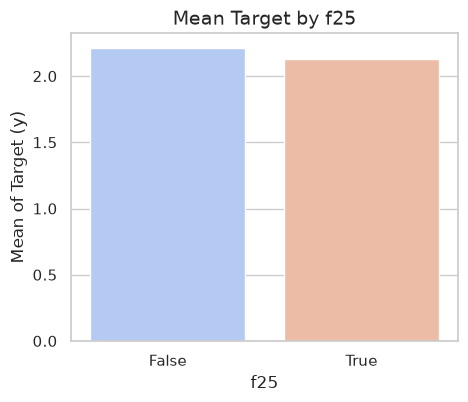

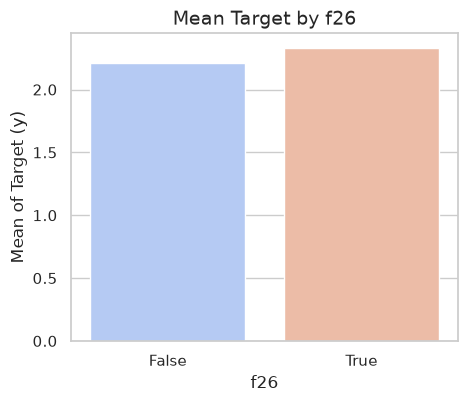

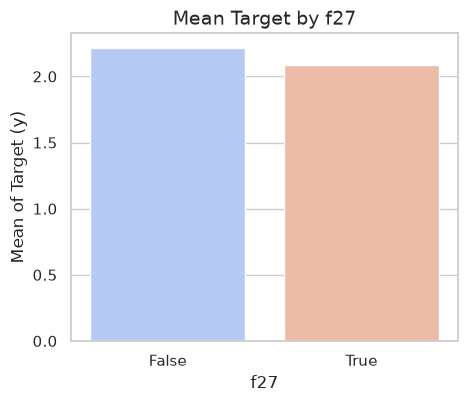

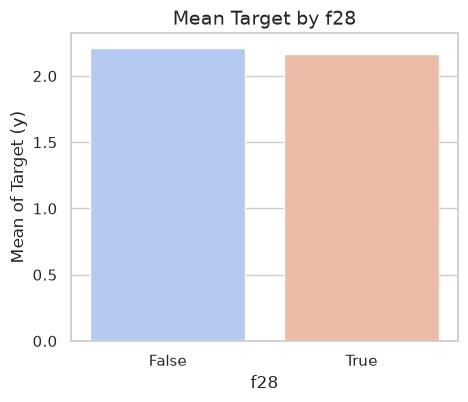

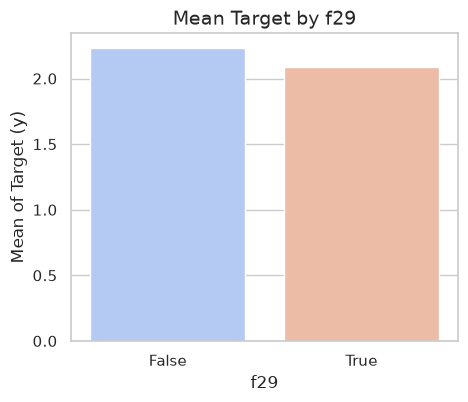

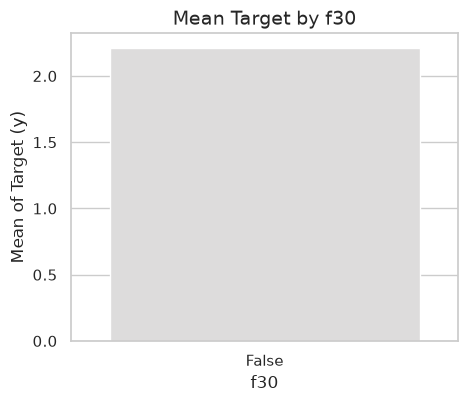

In [68]:
binary_cols = [col for col in df.columns if df[col].dropna().isin([True, False]).all()]

for col in binary_cols:
    
    target_mean = df.groupby(col)['y'].mean().reset_index()
    
    plt.figure(figsize=(5,4))
    sns.barplot(data=target_mean, x=col, y='y', palette='coolwarm')
    
    plt.title(f'Mean Target by {col}')
    plt.xlabel(col)
    plt.ylabel('Mean of Target (y)')
    
    plt.show()
